In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import START,END,StateGraph
from typing import  TypedDict,Annotated,Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
import operator 
import json

c:\projects\Langraph\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
llm=ChatGroq(model='qwen/qwen3-32b',api_key=os.getenv('Groq_API_KEY'))   

## Reply basis on setiment 

In [38]:
class sentimentschema(BaseModel):
    sentiment:Literal["positive", "negative","neutral"] =Field(description="Sentiment of the text")


In [39]:
sturctural_model=llm.with_structured_output(sentimentschema)
review="""
the product is great and I am very satisfied with the purchase
"""
prompt=f"""
You are a sentiment analysis model. You will be given a text and you need to classify the sentiment of text :{review}"""
sturctural_model.invoke(prompt)



sentimentschema(sentiment='positive')

In [65]:
class reviewschema(TypedDict):
    review: str
    sentiment: Literal["positive", "negative","neutral"]
    diagnosis: dict
    response:str
    


In [66]:
def findsentiment(state:reviewschema)->dict:
    review=state['review']
    prompt=f"""
    You are a sentiment analysis model. You will be given a text and you need to classify the sentiment of text :{review}"""
    result=sturctural_model.invoke(prompt)
    
    return{'sentiment':result.sentiment}

In [67]:
def check_sentiment(state:reviewschema)->Literal['positive_response','neutral_response','run_diagnosis']:
    if state['sentiment']=='positive':
        return 'positive_response'
    elif state['sentiment']=='neutral':
        return 'neutral_response'
    else:
        return 'run_diagnosis'

In [68]:
class daignisis_Schema(BaseModel):
    issue: str = Field(description="The issue identified in the review")
    tone: str = Field(description="The solution to the issue")
    urgencey:str

In [69]:
def positive_response(state:reviewschema)->reviewschema:
    prompt=f"""
write a response to the following review: {state['review']} thanking the user for their positive feedback and expressing appreciation for their support. The response should be polite, professional, and convey gratitude. and ask user to provide feedback on how we can improve our product and services. The response should be concise and to the point, and should not exceed 100 words.
"""
    response=llm.invoke(prompt)
    return {'response':response.content}

def neutral_response(state:reviewschema)->reviewschema:
    prompt=f"""
write a response to the following review: {state['review']} acknowledging the user's feedback and expressing appreciation for their input. The response should be polite and professional. The response should be concise and to the point, and should not exceed 100 words.
"""
    response=llm.invoke(prompt)
    return {'response':response.content}

def run_diagnosis(state:reviewschema)->reviewschema:
    prompt=f"""
    Diagnos the neagtive review :{state["review"]} and  return issue_type,tone and urgency of the review in a dictionary format. The issue_type should be a short description of the problem, the tone should be a short description of the sentiment of the review, and the urgency should be a short description of how quickly the issue needs to be addressed. The response should be concise and to the point, and should not exceed 100 words. 
    """
    response=llm.with_structured_output(daignisis_Schema).invoke(prompt)
    return {'diagnosis':response.model_dump()}

def  negative_response(state:reviewschema)->reviewschema:
    prompt=f""" 
write a response to the following review: {state['review']} apologizing for the negative experience and expressing a commitment to addressing the issue. The response should be polite, professional, and convey empathy. The response should be concise and to the point, and should not exceed 100 words.
    """
    response=llm.invoke(prompt)
    return {'response':response.content}


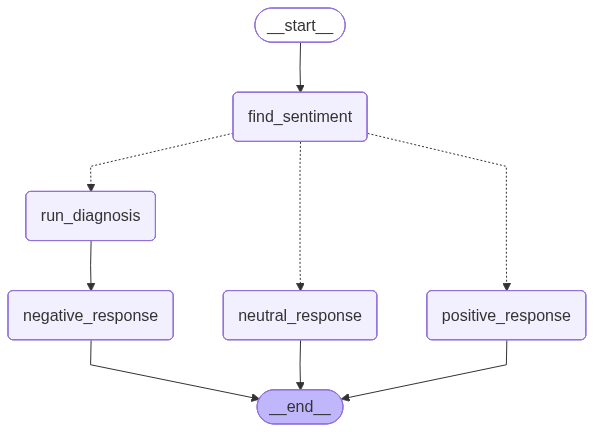

In [70]:
graph=StateGraph(reviewschema)

graph.add_node('find_sentiment',findsentiment)



graph.add_node('positive_response',positive_response)
graph.add_node('neutral_response',neutral_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)


graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('neutral_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)


workflow=graph.compile()
workflow


In [72]:
workflow.invoke({"review": "I am extremely disappointed with this product. It stopped working after just two days of use. I contacted customer support three times and haven't received any response. This has been a complete waste of money."})

{'review': "I am extremely disappointed with this product. It stopped working after just two days of use. I contacted customer support three times and haven't received any response. This has been a complete waste of money.",
 'sentiment': 'negative',
 'diagnosis': {'issue': 'Product malfunction and lack of customer support response',
  'tone': 'Highly negative and frustrated',
  'urgencey': 'High'},
 'response': "<think>\nOkay, let me start by understanding what the user needs. They want a response to a negative review. The review mentions that the product stopped working after two days and the customer didn't get a response from support. The user wants the response to apologize, express empathy, and commit to addressing the issue. It needs to be polite, professional, concise, and under 100 words.\n\nFirst, I should acknowledge their disappointment and apologize. Then, address the customer support issue, explaining that their concerns were not heard, which is a big problem. Offer a sol